<!-- GENERATED by scripts/build_problems.py from
     DA4CHE-admin/problems/Topic2.3-Complexity_Optimization/master.md
     Do not edit this file directly — your changes will be overwritten.
     Solutions and rubrics live in the private repo and must never appear here. -->

```{contents}
:local:
:depth: 2
```

# Problems: Complexity Optimization

:::{admonition} Get this problem set
:class: seealso

{download}`Download everything (Topic2.3-Complexity_Optimization_Problems.zip) <archives/Topic2.3-Complexity_Optimization_Problems.zip>` — the notebook and
`coffee_nmr.csv`, in a folder that is ready to run as-is.

The Download badge at the top of the page will also give you the notebook on its own.
On Vocareum everything is already set up for you.
:::

:::{admonition} Before you start
:class: tip

This problem set accompanies {doc}`Complexity Optimization </2-regression/Topic2.3-Complexity_Optimization>`. It is worth **100 points**:

- **Part A — Skill Checks (30 pts)** — short answers, auto-graded, resubmit as often as
  you like until they pass.
- **Part B — Visualization (35 pts)** — plots plus written interpretation, peer graded.
- **Part C — Open Ended (35 pts)** — one synthesis problem, peer graded.

The parts build on each other: Part A works out the syntax you need for Part B, and
Part B produces the evidence you argue from in Part C. Do them in order.
:::



## Setup

NMR spectra take time to collect, and the finer the resolution the longer the measurement
runs. So it is fair to ask how much of a spectrum you actually need. If we kept only every
twentieth point, could we rebuild the rest? That is a regression problem, and how well it
works depends on choosing the right model complexity.

The data here are proton NMR spectra of the lipophilic extract of ground roast Arabica
coffee. This is the fraction that holds the lipids and fatty acids, and food chemists use it
to tell one coffee from another. The measurements come from Gunning et al.,
*Food Chemistry* **248**, 52 (2018),
[doi:10.1016/j.foodchem.2017.12.034](https://doi.org/10.1016/j.foodchem.2017.12.034).

The file holds one window, 0.80 to 1.70 ppm, sampled at 704 points, for three coffee
samples. This window was chosen because the peaks in it differ so much in height: there is a
large methylene peak near 1.26 ppm and several much smaller ones beside it. A single kernel
width has to cover both, which is what makes the complexity choice matter here.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
try:
    plt.style.use('../settings/plot_style.mplstyle')   # available inside the book
except OSError:
    pass                                              # downloaded notebook: use defaults

df = pd.read_csv('data/coffee_nmr.csv')
shift = df['shift_ppm'].values
y = df['CS01'].values
X = shift.reshape(-1, 1)          # scikit-learn wants one column, not one row

n = len(shift)
# The split is written as a rule about the index, not as a slice, because Part C needs
# three training sets that nest inside one another and that is easier to see this way.
i_test = np.array([i for i in range(n) if i % 10 != 0])   # 633 pts, never trained on
i_train = np.array([i for i in range(n) if i % 20 == 0])  # 36 pts, Parts A and B

print(f"{n} points, {shift.min():.4f} to {shift.max():.4f} ppm, "
      f"spacing {shift[1] - shift[0]:.5f} ppm")
print(f"training set {len(i_train)} points, spacing {shift[20] - shift[0]:.4f} ppm")
print(f"test set     {len(i_test)} points")

704 points, 0.8004 to 1.6988 ppm, spacing 0.00128 ppm
training set 36 points, spacing 0.0256 ppm
test set     633 points


:::{note}
**One test set, three training sets.** Part C trains on every 10th, every 20th and every
40th point. These three sets are nested: every 40th point is also every 20th, and every 20th
is also every 10th. So we reserve every index divisible by 10, and `i_test` is the 633 points
left over. Using one fixed test set for all of them is what lets you compare Part C's three
rows directly. If each density were scored against its own leftovers, the three numbers would
come from three different test sets and could not be lined up.

Nothing here uses `train_test_split`. The split is deterministic, so there is no
`random_state` anywhere and none of your answers depend on a seed.
:::

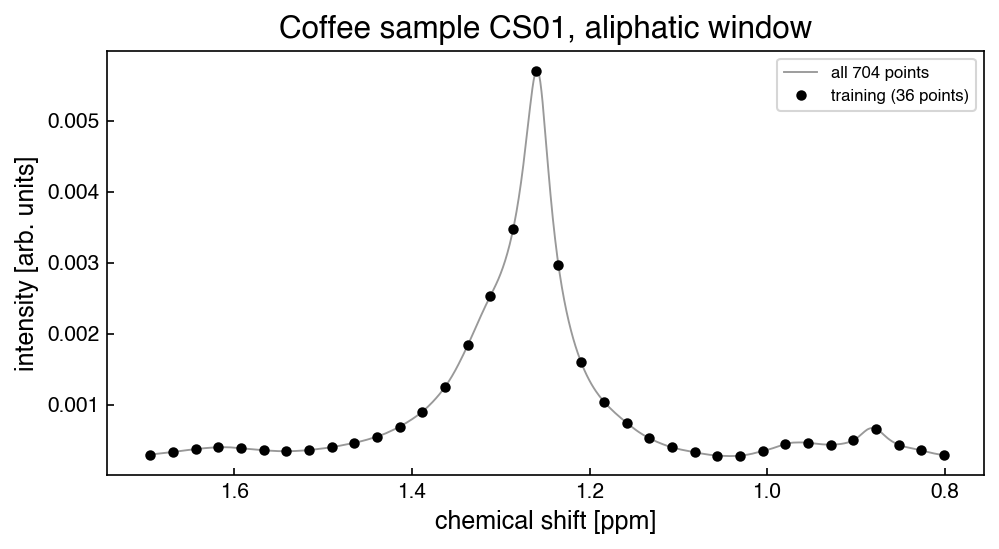

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shift, y, '-', lw=0.9, color='0.6', label='all 704 points')
ax.plot(shift[i_train], y[i_train], 'ko', ms=4, label=f'training ({len(i_train)} points)')
ax.set_xlabel('chemical shift [ppm]')
ax.set_ylabel('intensity [arb. units]')
ax.set_title('Coffee sample CS01, aliphatic window')
ax.invert_xaxis()                 # NMR spectra are drawn with shift decreasing
ax.legend(fontsize=8);

The model throughout is kernel ridge regression with the radial basis function kernel, as
in the chapter:

$$
K_{ij} = \exp\!\left(-\gamma\,(x_i - x_j)^2\right),
\qquad
\gamma = \frac{1}{2\sigma^2},
$$

It has two hyperparameters, and this problem set is about choosing them:

- $\sigma$, the **kernel width**, in ppm — how far one measurement's influence reaches.
- $\alpha$, the **regularization strength** — how strongly large coefficients are penalized.

In scikit-learn this is `KernelRidge(kernel='rbf', alpha=alpha, gamma=gamma)`. Note that it
takes $\gamma$ rather than $\sigma$, so converting between the two is the first thing to get
right.

Run this once. It defines the `check` helper used after each Part A answer. It will
not run inside the book — use the downloaded notebook.

In [ ]:
# Run this once. It defines `check`, used after each Part A answer below.
import hashlib

_EXPECTED = {
    'q1': (7, ['98bc529e03cf', 'd3d417e465e8', '58b464af71ce', '9a606e68e5b7', '47901bd675f8', '8cc2a2ff00ce', 'd9088a3e2036', 'a476e07923da', '70cf47ddf33b', '3b36c3b24b1e', '9b8563f27aa3']),
    'q2': (4, ['6fba6daf702e', '2f0456c6a967', 'ff42fd7b8660', '9dd841b19e85', 'e0af7d47fb6d', 'a01d90511560', 'e132dc961afa', '8da57ece22cb', 'f9d42113a005', 'e22d118b4199', '7a6360713029']),
    'q3': (6, ['bde167485f11', '835434230103', '5403115ab6ff', 'a4853cac7d1a', '3a98ce353e50', '5665f9f3eee1', '3d8ea8a5c89b', '3e0549477122', 'b9e88dbb5a17', '6dea55f19c07', '952bcb21b556', '6b4111d39aa6', '33517f0d5088', 'b55f2aa6e20c', '673f026a51b7', 'fa90b332e2ef', '55ab4977c932', 'eeb890cbfdb5', 'ac4d3319b7b5', '0541c2f27bdb', '9a10e6521459']),
}

def check(qid, value):
    """Compare an answer against a stored digest. Practice only -- nothing is recorded."""
    places, digests = _EXPECTED[qid]
    if value is Ellipsis:
        print(f"{qid}: not answered yet")
        return
    got = hashlib.sha256(f"{float(value):.{places}f}".encode()).hexdigest()[:12]
    print(f"{qid}: {'correct' if got in digests else 'not the expected value'}")

---

## Part A — Skill Checks (30 pts)

Three questions, 10 points each. Each asks you to assign a single number to a named
variable. Run the check cell after each one; there is no limit on attempts.

All three train on `i_train`, the 36-point subsample; A2 and A3 score on `i_test`. A1 fixes
both hyperparameters, A2 changes one to see what it costs, and A3 searches for the best pair.

### A1. Fit the model and predict between two measurements (10 pts)

:::{exercise}
:label: pr-reg-krr-predict

Fit `KernelRidge` with the RBF kernel to the 36 training points, using

$$
\sigma = 0.02 \ \text{ppm}, \qquad \alpha = 10^{-4},
$$

remembering that the constructor takes $\gamma = 1/(2\sigma^2)$ rather than $\sigma$.

Then predict the intensity at a chemical shift of **1.25 ppm**. This is not one of the 704
measured points, and it sits about 0.010 ppm from the nearest training point, on the side of
the large peak where the curve is steepest.

Assign the prediction to `y_pred`.
:::

In [ ]:
# YOUR CODE HERE
y_pred = ...

In [ ]:
check("q1", y_pred)

### A2. Narrow the kernel and score it honestly (10 pts)

:::{exercise}
:label: pr-reg-narrow-kernel

Now change one thing. Refit the same model on the same 36 training points with

$$
\sigma = 0.005 \ \text{ppm}, \qquad \alpha = 10^{-8},
$$

a kernel four times narrower than A1's.

Report the $r^2$ of this model on the **test set**, `i_test` — the 633 points it was not
trained on. Use `r2_score`, or the model's own `.score()`.

Assign it to `r2_test_narrow`.

*Compute the $r^2$ on the training points as well and keep both numbers handy. The training
value is not graded, but you will need it in Part B, and the relationship between the two is
what this problem set is about.*
:::

In [ ]:
# YOUR CODE HERE
r2_test_narrow = ...

In [ ]:
check("q2", r2_test_narrow)

### A3. Search both hyperparameters (10 pts)

:::{exercise}
:label: pr-reg-grid-optimum

A1 and A2 each fixed both hyperparameters by hand. Now search. Over the grid

```
sigmas = [0.005, 0.01, 0.02, 0.04, 0.08]
alphas = [1e-8, 1e-6, 1e-4, 1e-2, 1e0]
```

fit all 25 models on `i_train` and score each on `i_test`. Report the **largest test $r^2$**
you find.

Assign it to `r2_test_best`.

*Both hyperparameters have to move. The chapter warns that they can be coupled, and they are
here: sweeping $\sigma$ alone with $\alpha$ fixed at $10^{-4}$ gets close, but does not reach
the best value on this grid.*
:::

In [ ]:
# YOUR CODE HERE
r2_test_best = ...

In [ ]:
check("q3", r2_test_best)

---

## Part B — Visualization (35 pts)

In A2 you fit a model that scored a perfect 1.000000 on its training points and did far worse
on the points it had not seen. This part plots that, then looks at two things you might expect
to settle the complexity question for you.

You need two helpers from the chapter: the information criterion, and a Gaussian basis with
`N` evenly spaced centers. The second is a different model from kernel ridge, because its
complexity is the *number* of basis functions rather than their width.

:::{admonition} What an "edge optimum" is, and why it matters in task 3
:class: note

Whenever you pick a hyperparameter off a grid, look at *where* on the grid the winner sits. A
grid search only tells you the best of the values you asked about, so a winner at the smallest
or largest value you tried usually means something better lies just outside the range. The
chapter states this as a rule:

> **Do not accept an "edge" optimum.** If the best score occurs at the **minimum or maximum**
> of any grid axis, **expand that axis** and re-run.

A winner in the middle is what you want: values on both sides were tried and were worse, so
the search has bracketed the optimum. Task 3 applies this test to a case where it fails, and
where the usual fix is not available.
:::

In [3]:
def BIC(y_true, y_hat, k):
    """Bayesian information criterion, as defined in the chapter."""
    err = y_true - y_hat
    return len(y_true) * np.log(np.std(err) ** 2) + k * np.log(len(y_true))


def gaussian_features(x_eval, centers, width):
    """One Gaussian bump per center, evaluated at x_eval. Rows are points, columns basis."""
    return np.exp(-((x_eval[:, None] - centers[None, :]) ** 2) / (2 * width ** 2))

::::{exercise}
:label: pr-reg-complexity-curve

**1. Three complexities, one spectrum.** Fit kernel ridge on `i_train` at
$\sigma = 0.005$, $0.02$ and $0.08$, holding $\alpha = 10^{-4}$. For each, plot the model
over all 704 shifts together with the measured curve and the 36 training points, and report
its training $r^2$ and its test $r^2$. Three plots; arrange them however you like.

Then, in **two sentences**: say which of the three is overfit and which is underfit, and
state what the training $r^2$ column does and does not tell you about that.

**2. The complexity curve.** Sweep

```
sigmas = [0.0025, 0.005, 0.01, 0.02, 0.04, 0.08, 0.16]
```

at $\alpha = 10^{-4}$, and plot training $r^2$ and test $r^2$ against $\sigma$ on a
**logarithmic** $\sigma$ axis, with a vertical line at the $\sigma$ that maximizes the test
score. Clip the $y$ axis so the curve is readable.

In **one sentence**: say over what range of $\sigma$ the training score is unable to
distinguish between these models, and what the test score is doing across that same range.

**3. A criterion that selects nothing.** Now the parametric model. For
`N` in `range(2, 35, 2)`, place `N` evenly spaced centers across the window, set each bump's
`width` to the spacing between adjacent centers, fit `LinearRegression(fit_intercept=False)`
on `i_train`, and record `BIC(...)` on the training points along with the test $r^2$. Plot
BIC against `N`, and report the `N` that minimizes it.

Then, in **two sentences**: say what the rule above tells you about the `N` you found, and
why you cannot fix it the way the rule says to.

:::{note}
The grid stops at `N = 34` on purpose. There are 36 training points, so at `N = 36` the
basis can pass through all of them exactly, the residuals go to zero, and $\ln(\sigma_e^2)$
goes to minus infinity — BIC returns whatever the floating-point noise in a vanishing
residual happens to be. Nothing to learn from a number like that, so the grid stays below it.
:::

**4. When does $\alpha$ matter?** So far $\alpha$ has been held fixed. Using the same grid as
A3, make two plots side by side:

- **Left:** test $r^2$ against $\alpha$, with a logarithmic $\alpha$ axis and **one curve per
  $\sigma$**. Label the curves.
- **Right:** the size of the fitted coefficients, `np.linalg.norm(model.dual_coef_)`, against
  $\sigma$, with both axes logarithmic, at fixed $\alpha = 10^{-4}$.

In **one sentence**: say which kernel widths are barely affected by the choice of $\alpha$ and
which are strongly affected, and what the right-hand plot suggests is different about them.
::::

In [ ]:
# YOUR CODE HERE
fig, ax = plt.subplots()

---

## Part C — Open Ended (35 pts)

So far the training set has been fixed at 36 points and the model has moved. This part does
the opposite: the search stays the same and the amount of training data changes, which is what
an experimentalist actually controls. That answers the question the Setup started with — how
coarsely could this spectrum have been sampled?

Three training densities, nested so that they all share the one test set:

```
densities = [10, 20, 40]          # every 10th, every 20th, every 40th point
```

For each, the training set is `[i for i in range(n) if i % d == 0]` and `i_test` is
unchanged. Because 40 and 20 are multiples of 10, those three sets nest inside one another
and none of them touches `i_test`. Reuse the A3 grid throughout:

```
sigmas = [0.005, 0.01, 0.02, 0.04, 0.08]
alphas = [1e-8, 1e-6, 1e-4, 1e-2, 1e0]
```

:::{admonition} `CS02` and `CS03` are a validation set — keep them out of the fitting
:class: warning

Nothing in this problem set has touched `CS02` or `CS03` so far, and nothing you do now may
fit them or use them to choose $\sigma$ or $\alpha$. Treat them as two spectra measured
*after* your model was finished: they arrive, you run the model on them once, and whatever
comes out is the number you report.

That restriction is what makes them worth having. Every score so far has been measured on
`i_test`, which is exactly what you tuned $\sigma$ and $\alpha$ against in A3 and in task 1
below. In the chapter's terminology that makes `i_test` a **test** set rather than a
**validation** set: it helped set the model up, so a score measured on it is optimistic. The
chapter calls this **data leakage** and lists hyperparameter tuning first:

> Once data has been used to optimize the hyperparameters of a model, the model is biased
> toward that data. [...] If you want the most reliable evaluation of how your model will
> perform on new data, you should use the performance on the *validation* set that is not
> used in any way in hyperparameter tuning.

`CS02` and `CS03` are that validation set. They are the only numbers here that nothing has
been tuned against, and task 4 is where you find out what the tuning was worth.

They serve a second purpose in task 5: two separately prepared extracts differ for real
reasons — the beans, the extraction, the sample tube — so the agreement between them tells you
how close any model of one spectrum could sensibly be asked to get.
:::

::::{exercise}
:label: pr-reg-data-density

**1. Optimal complexity at three densities.** For each density, run the full 25-point grid
search on that training set, scoring on `i_test`. Report a table with one row per density: the
number of training points, the spacing between them in ppm, the $\sigma$ and $\alpha$ that
win, and the best test $r^2$.

**2. How the optimum moves.** Plot the winning $\sigma$ against the number of training points,
and the best test $r^2$ against the number of training points. In **one sentence**: say which
way the optimal kernel width moves as training data is removed, and why that is the direction
to expect.

**3. What a fixed hyperparameter costs.** Now suppose you tuned once and never again. At the
single setting $\sigma = 0.005$, $\alpha = 10^{-8}$, report the training $r^2$ **and** the test
$r^2$ at all three densities. In **one sentence**: say what the training column does as data is
removed, and what the test column does.

**4. Score the models on data nothing was tuned against.** Take the winning model at each
density from task 1 and use it to predict `CS02` and `CS03` over `i_test`. Report three numbers
per density: the test $r^2$ from task 1, and the $r^2$ against each of the two unseen spectra.

In **one sentence**: say how far the unseen-sample scores sit below the number you tuned to,
and which of the three you would quote if you had to report a single figure for this model.

**5. How sparsely could this spectrum have been sampled?** As a reference, compute the $r^2$
of `CS01` used directly as a prediction of `CS02`, and the same for `CS03` — no model, one
spectrum standing in for another. That is how well two real coffees agree.

Using those numbers and task 4's, state a criterion and name the sparsest of the three
densities that meets it. In **one or two sentences**, justify the criterion and say what it
implies about how much of this spectrum was needed. More than one answer is defensible, and
the two references disagree, so say which you are using.
::::

In [ ]:
# YOUR CODE HERE
densities = [10, 20, 40]